In [71]:
! pip install grad-cam

In [72]:
import torch
from torchvision import transforms
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import os
import random

from PIL import Image
import numpy as np

## Load the data

In [73]:
data_dir = '/media/shadab/Others/Liver_Fibrosis_US_processed'

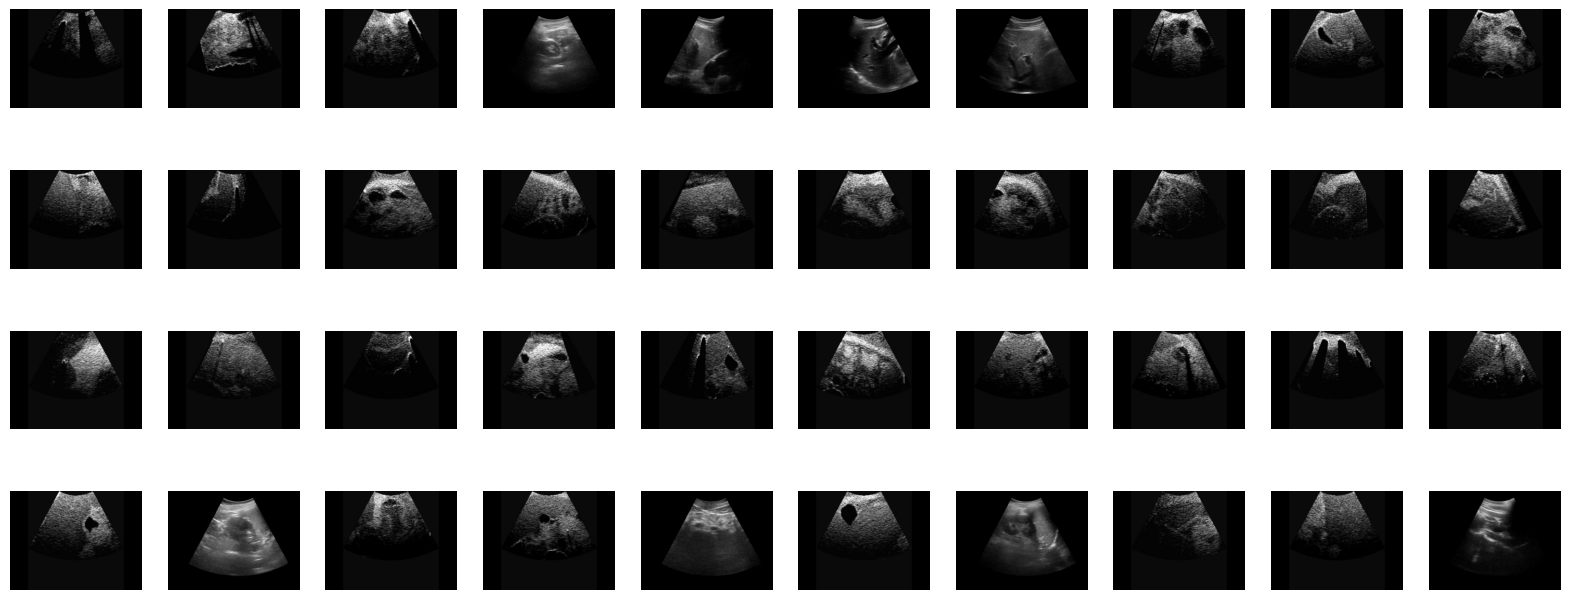

In [74]:
# Print 10 sample images from each class
classes = os.listdir(data_dir)


num_classes = len(classes)
fig, axes = plt.subplots(num_classes, 10, figsize=(20, 2 * num_classes))


for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    images = os.listdir(cls_path)[:10]
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img, cmap='gray')
        axes[i, j].axis('off')
    axes[i, 0].set_ylabel(cls, size='large')

plt.show()

## Load the model

In [75]:
print("\n" + "="*80)
print("LOADING TRAINED MODELS")
print("="*80)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load DenseNet201 model for US images
densenet_model_path = '../Models/Ultrasound/Densenet201/densenet201_full_model.pt'
print(f"\nLoading DenseNet201 from: {densenet_model_path}")
densenet_model = torch.load(densenet_model_path, map_location=device, weights_only=False)
densenet_model.eval()
print("✅ DenseNet201 loaded successfully")


LOADING TRAINED MODELS
Using device: cpu

Loading DenseNet201 from: ../Models/Ultrasound/Densenet201/densenet201_full_model.pt
✅ DenseNet201 loaded successfully


In [76]:
print(densenet_model)

DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

## Test Grad-CAM on sample images

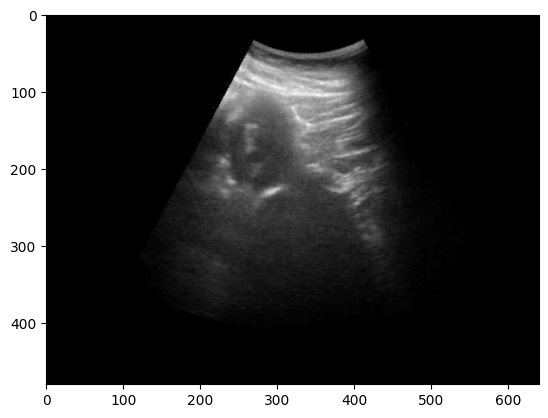

In [77]:
image = os.path.join(data_dir, 'F1', 'a13.jpg')


img = mpimg.imread(image)
plt.imshow(img, cmap='gray')


### Get prediction from the model

In [78]:
# Convert to numpy array
arr = np.array(img)

# If grayscale, duplicate channels to make 3 channels
if arr.ndim == 2:
    arr = np.stack([arr, arr, arr], axis=-1)

# Discard the alpha channel if present
elif arr.shape[2] == 4:
    arr = arr[:, :, :3]

# Convert to float32 and scale to [0,1]
arr = arr.astype(np.float32)
if arr.max() > 1.0:
    arr /= 255.0


input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    output = densenet_model(input_tensor)
    pred = int(output.argmax(dim=1).item())

target = 0
target_name = classes[target]
pred_name = classes[pred]
print(f"Target: {target_name} ({target}) | Predicted: {pred_name} ({pred})")

Target: F1 (0) | Predicted: F1 (0)


### Grad-CAM Visualization

In [79]:
# Define the target layer and target class
classes = [ClassifierOutputTarget(0)]
layers = [densenet_model.features[-1]]

In [80]:
cam = GradCAM(model=densenet_model, target_layers=layers)
heatmap = cam(input_tensor=input_tensor, targets=classes)

(np.float64(-0.5), np.float64(639.5), np.float64(479.5), np.float64(-0.5))

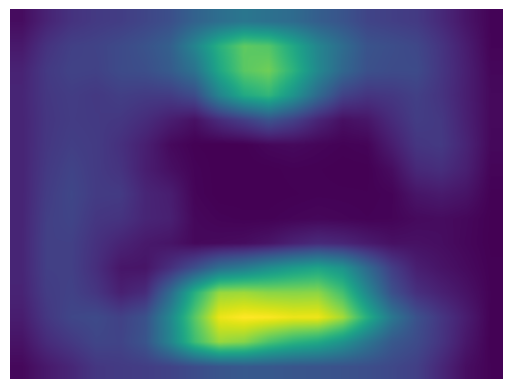

In [81]:
plt.imshow(heatmap[0])
plt.axis('off')

Plot it as an overlay on the original image

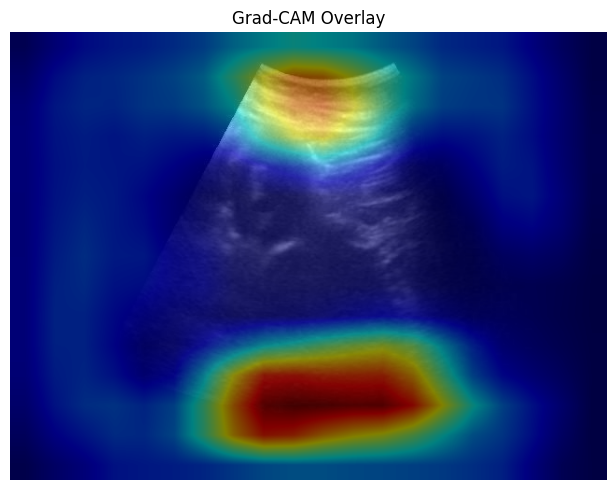

In [82]:
try:
    rgb_img = arr.copy()    
except NameError:
    rgb_img = np.array(img)

# Ensure 3 channels
if rgb_img.ndim == 2:
    rgb_img = np.stack([rgb_img, rgb_img, rgb_img], axis=-1)
elif rgb_img.shape[2] == 4:
    rgb_img = rgb_img[:, :, :3]

# Convert to float32 in [0,1]
rgb_img = rgb_img.astype(np.float32)
if rgb_img.max() > 1.0:
    rgb_img /= 255.0

# Create overlay 
visualization = show_cam_on_image(rgb_img, heatmap[0], use_rgb=True)

# Display original and overlay
plt.figure(figsize=(10,5))
plt.title('Grad-CAM Overlay')
plt.imshow(visualization)
plt.axis('off')

plt.tight_layout()
plt.show()

### F1 Class

In [83]:
f1_data_dir = os.path.join(data_dir, 'F1')
f1_images = os.listdir(f1_data_dir)
print(f"Number of F1 images: {len(f1_images)}")

Number of F1 images: 859


In [84]:
all_imgs = [os.path.join(f1_data_dir, f) for f in os.listdir(f1_data_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
n_to_show = min(5, len(all_imgs))
selected = random.sample(all_imgs, n_to_show)
print(f"Selected images: {selected}")


Selected images: ['/media/shadab/Others/Liver_Fibrosis_US_processed/F1/c3.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F1/ct1-12.png', '/media/shadab/Others/Liver_Fibrosis_US_processed/F1/ct2-64.png', '/media/shadab/Others/Liver_Fibrosis_US_processed/F1/I1703.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F1/C9467.jpg']


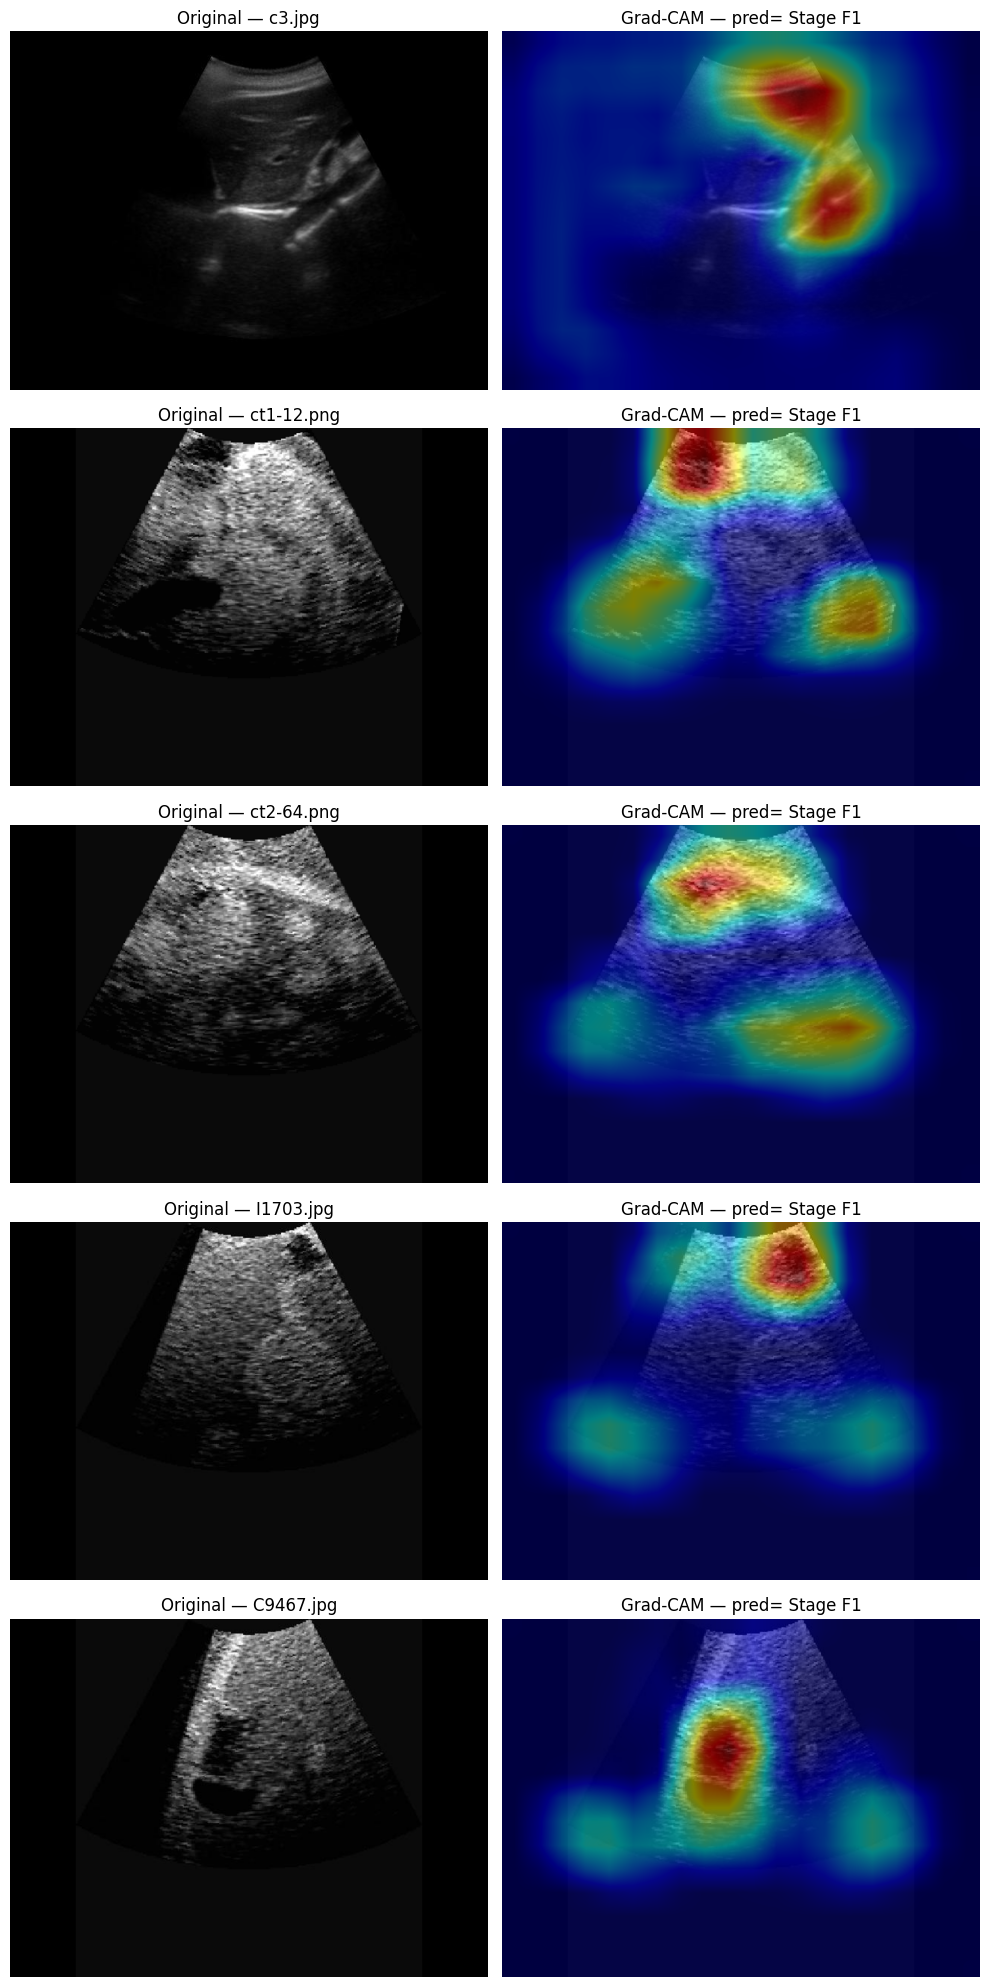

In [85]:
cam = GradCAM(model=densenet_model, target_layers=layers)

plt.figure(figsize=(10, 4 * n_to_show))
for i, img_path in enumerate(selected):
    # load and prepare image (HxWx3 float32 in [0,1])
    img = mpimg.imread(img_path)
    arr = np.array(img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0

    # convert to tensor and move to device
    input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    # get prediction to target that class
    with torch.no_grad():
        out = densenet_model(input_tensor)
        pred = int(out.argmax(dim=1).item())

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # overlay and plot
    vis = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

    plt.subplot(n_to_show, 2, 2 * i + 1)
    plt.imshow(arr)
    plt.title(f'Original — {os.path.basename(img_path)}')
    plt.axis('off')

    plt.subplot(n_to_show, 2, 2 * i + 2)
    plt.imshow(vis)
    plt.title(f'Grad-CAM — pred= Stage F{pred + 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### F2 Class

In [86]:
f2_data_dir = os.path.join(data_dir, 'F2')
f2_images = os.listdir(f2_data_dir)
print(f"Number of F2 images: {len(f2_images)}")

Number of F2 images: 783


In [89]:
all_imgs = [os.path.join(f2_data_dir, f) for f in os.listdir(f2_data_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
n_to_show = min(5, len(all_imgs))
selected = random.sample(all_imgs, n_to_show)
print(f"Selected images: {selected}")

Selected images: ['/media/shadab/Others/Liver_Fibrosis_US_processed/F2/o819.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F2/U5455.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F2/T4533.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F2/n6688.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F2/ct4-75.png']


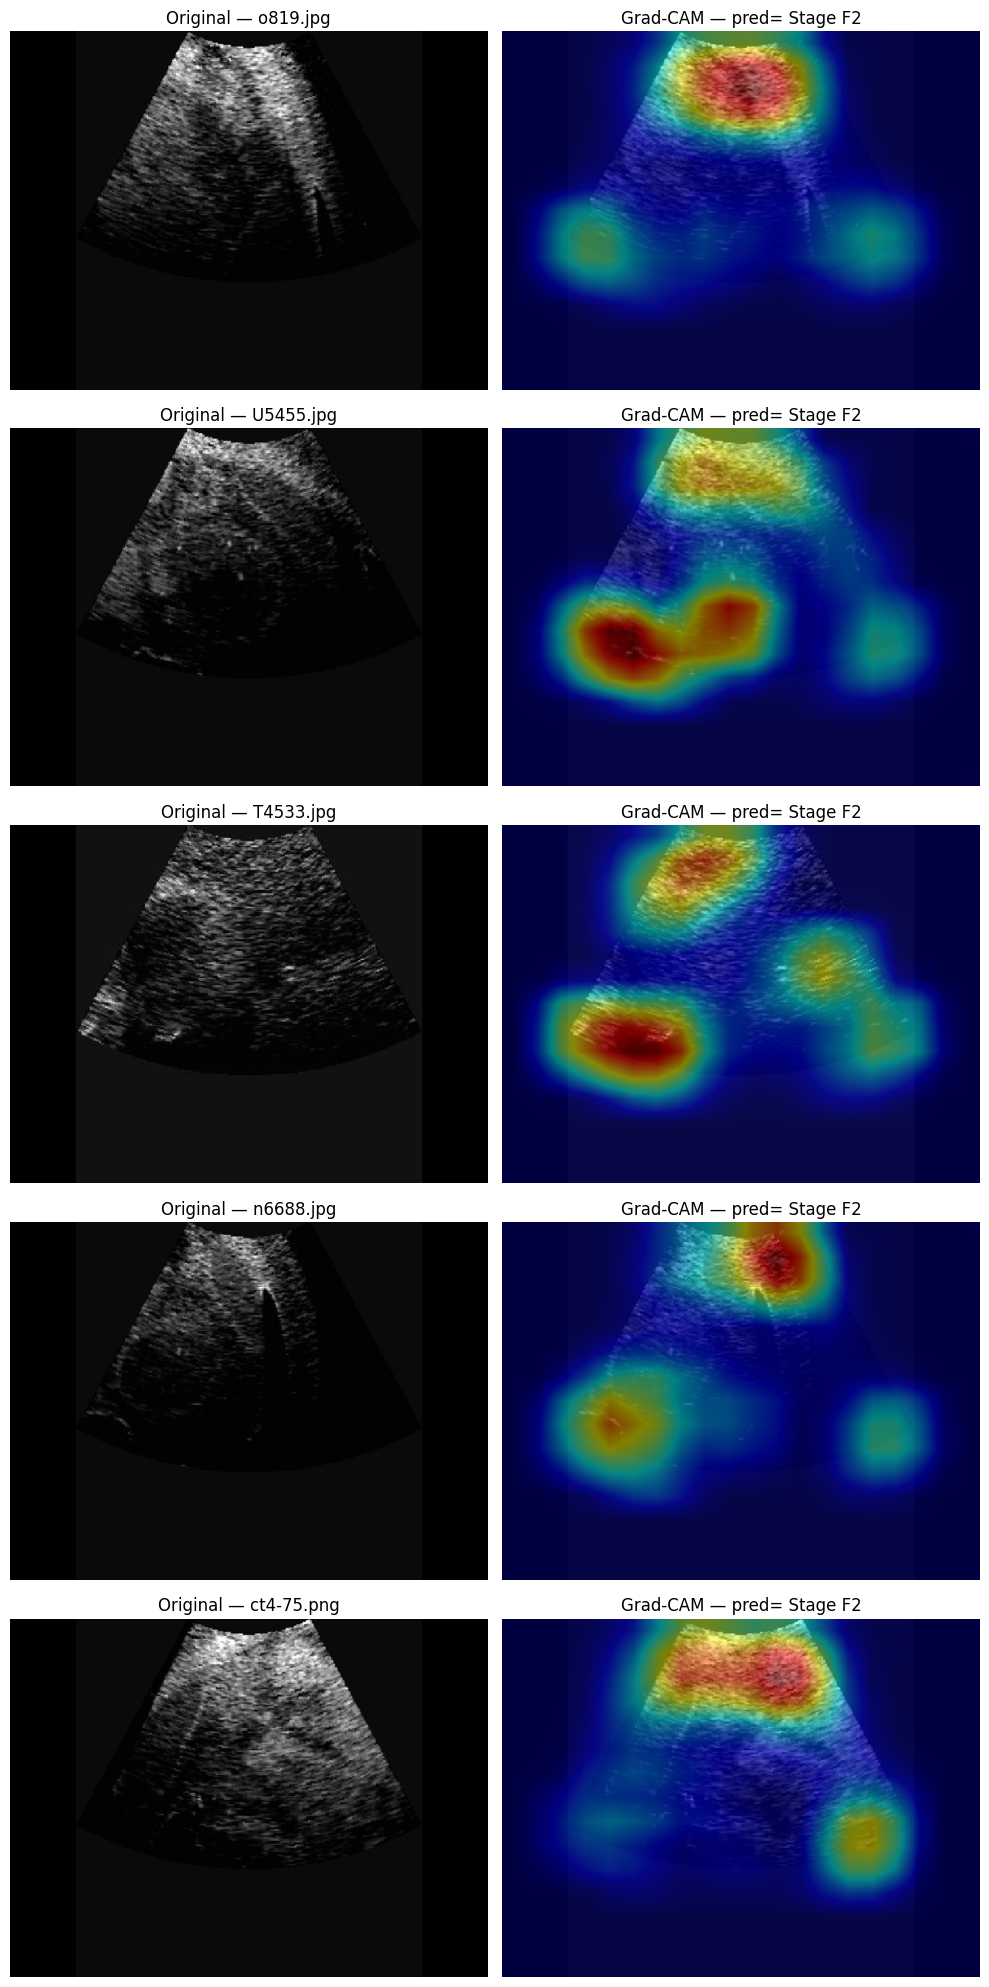

In [90]:
cam = GradCAM(model=densenet_model, target_layers=layers)

plt.figure(figsize=(10, 4 * n_to_show))
for i, img_path in enumerate(selected):
    # load and prepare image (HxWx3 float32 in [0,1])
    img = mpimg.imread(img_path)
    arr = np.array(img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0

    # convert to tensor and move to device
    input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    # get prediction to target that class
    with torch.no_grad():
        out = densenet_model(input_tensor)
        pred = int(out.argmax(dim=1).item())

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # overlay and plot
    vis = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

    plt.subplot(n_to_show, 2, 2 * i + 1)
    plt.imshow(arr)
    plt.title(f'Original — {os.path.basename(img_path)}')
    plt.axis('off')

    plt.subplot(n_to_show, 2, 2 * i + 2)
    plt.imshow(vis)
    plt.title(f'Grad-CAM — pred= Stage F{pred + 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### F3 Class

In [91]:
f3_data_dir = os.path.join(data_dir, 'F3')
f3_images = os.listdir(f3_data_dir)
print(f"Number of F3 images: {len(f3_images)}")

Number of F3 images: 839


In [92]:
all_imgs = [os.path.join(f3_data_dir, f) for f in os.listdir(f3_data_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
n_to_show = min(5, len(all_imgs))
selected = random.sample(all_imgs, n_to_show)
print(f"Selected images: {selected}")

Selected images: ['/media/shadab/Others/Liver_Fibrosis_US_processed/F3/V9637.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F3/T8189.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F3/T2861.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F3/q7296.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F3/ct11-53.png']


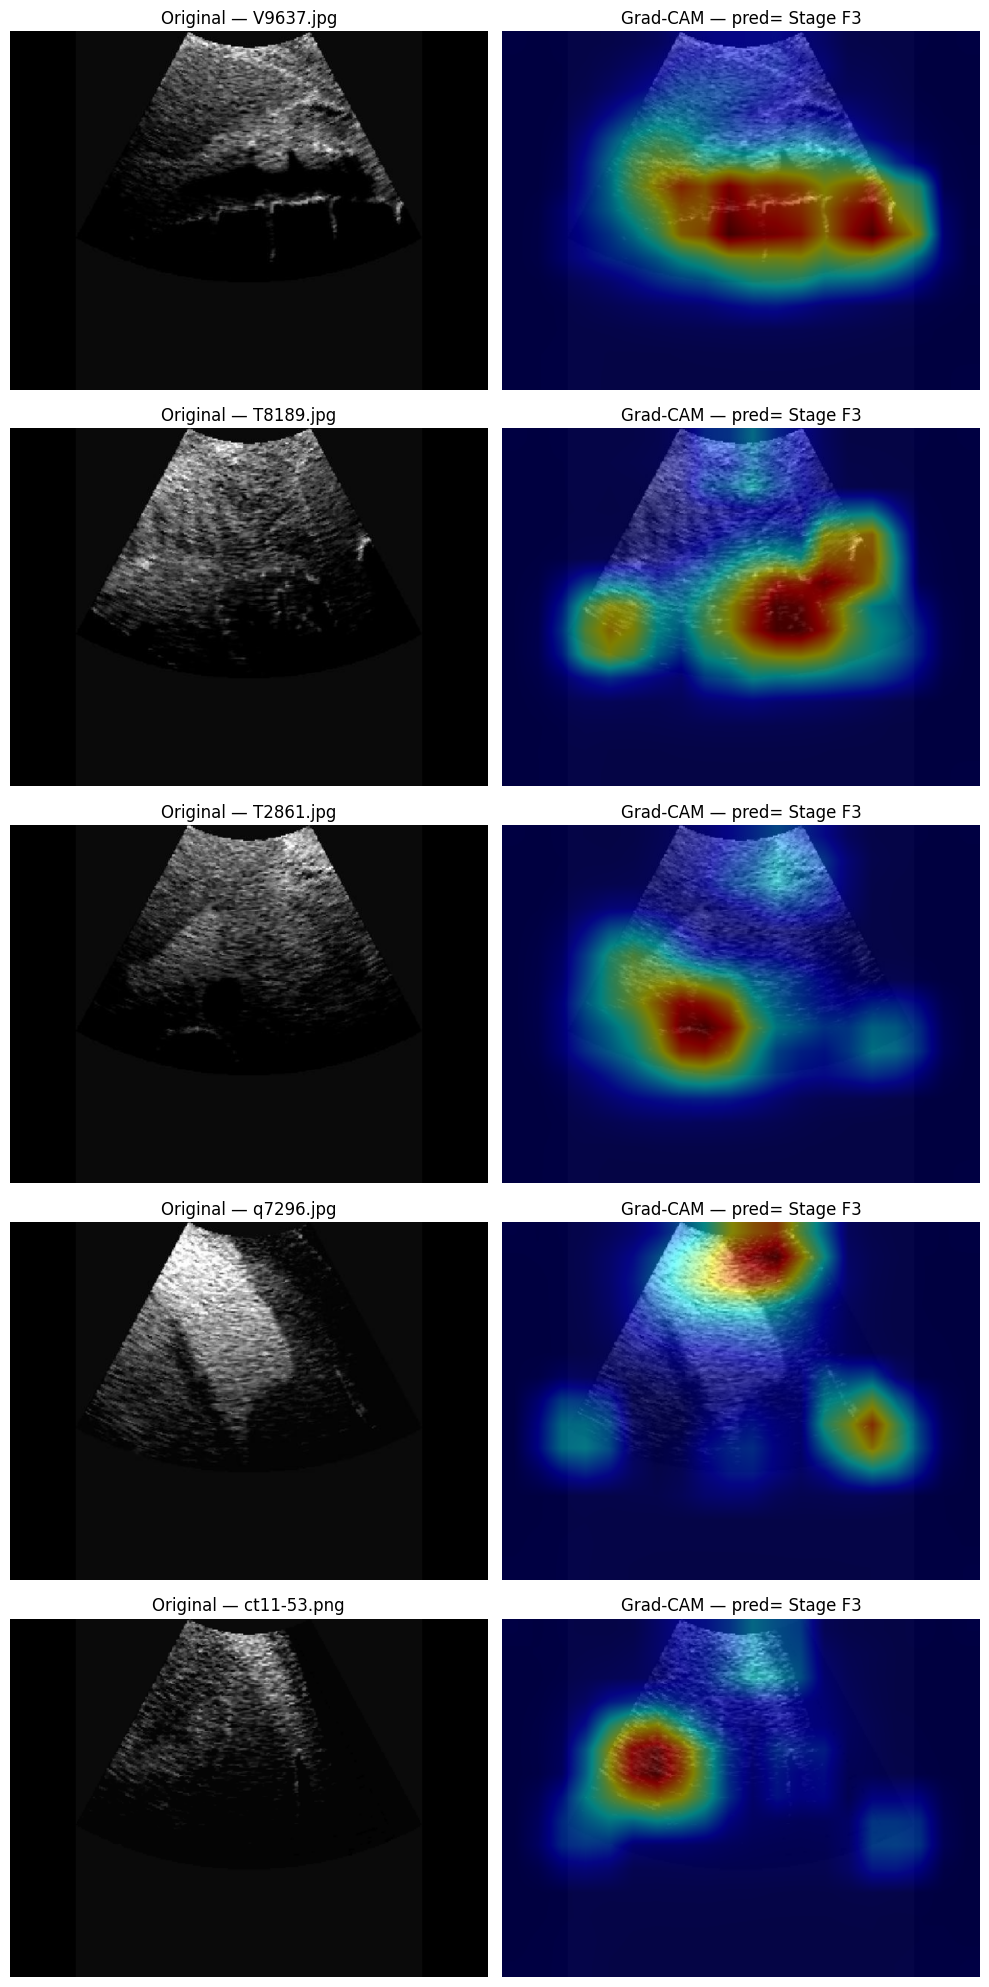

In [93]:
cam = GradCAM(model=densenet_model, target_layers=layers)

plt.figure(figsize=(10, 4 * n_to_show))
for i, img_path in enumerate(selected):
    # load and prepare image (HxWx3 float32 in [0,1])
    img = mpimg.imread(img_path)
    arr = np.array(img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0

    # convert to tensor and move to device
    input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    # get prediction to target that class
    with torch.no_grad():
        out = densenet_model(input_tensor)
        pred = int(out.argmax(dim=1).item())

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # overlay and plot
    vis = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

    plt.subplot(n_to_show, 2, 2 * i + 1)
    plt.imshow(arr)
    plt.title(f'Original — {os.path.basename(img_path)}')
    plt.axis('off')

    plt.subplot(n_to_show, 2, 2 * i + 2)
    plt.imshow(vis)
    plt.title(f'Grad-CAM — pred= Stage F{pred + 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()

### F4 Class

In [94]:
f4_data_dir = os.path.join(data_dir, 'F4')
f4_images = os.listdir(f4_data_dir)
print(f"Number of F4 images: {len(f4_images)}")

Number of F4 images: 1670


In [95]:
all_imgs = [os.path.join(f4_data_dir, f) for f in os.listdir(f4_data_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp'))]
n_to_show = min(5, len(all_imgs))
selected = random.sample(all_imgs, n_to_show)
print(f"Selected images: {selected}")

Selected images: ['/media/shadab/Others/Liver_Fibrosis_US_processed/F4/Q8384.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F4/j3786.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F4/f2.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F4/s9625.jpg', '/media/shadab/Others/Liver_Fibrosis_US_processed/F4/U771.jpg']


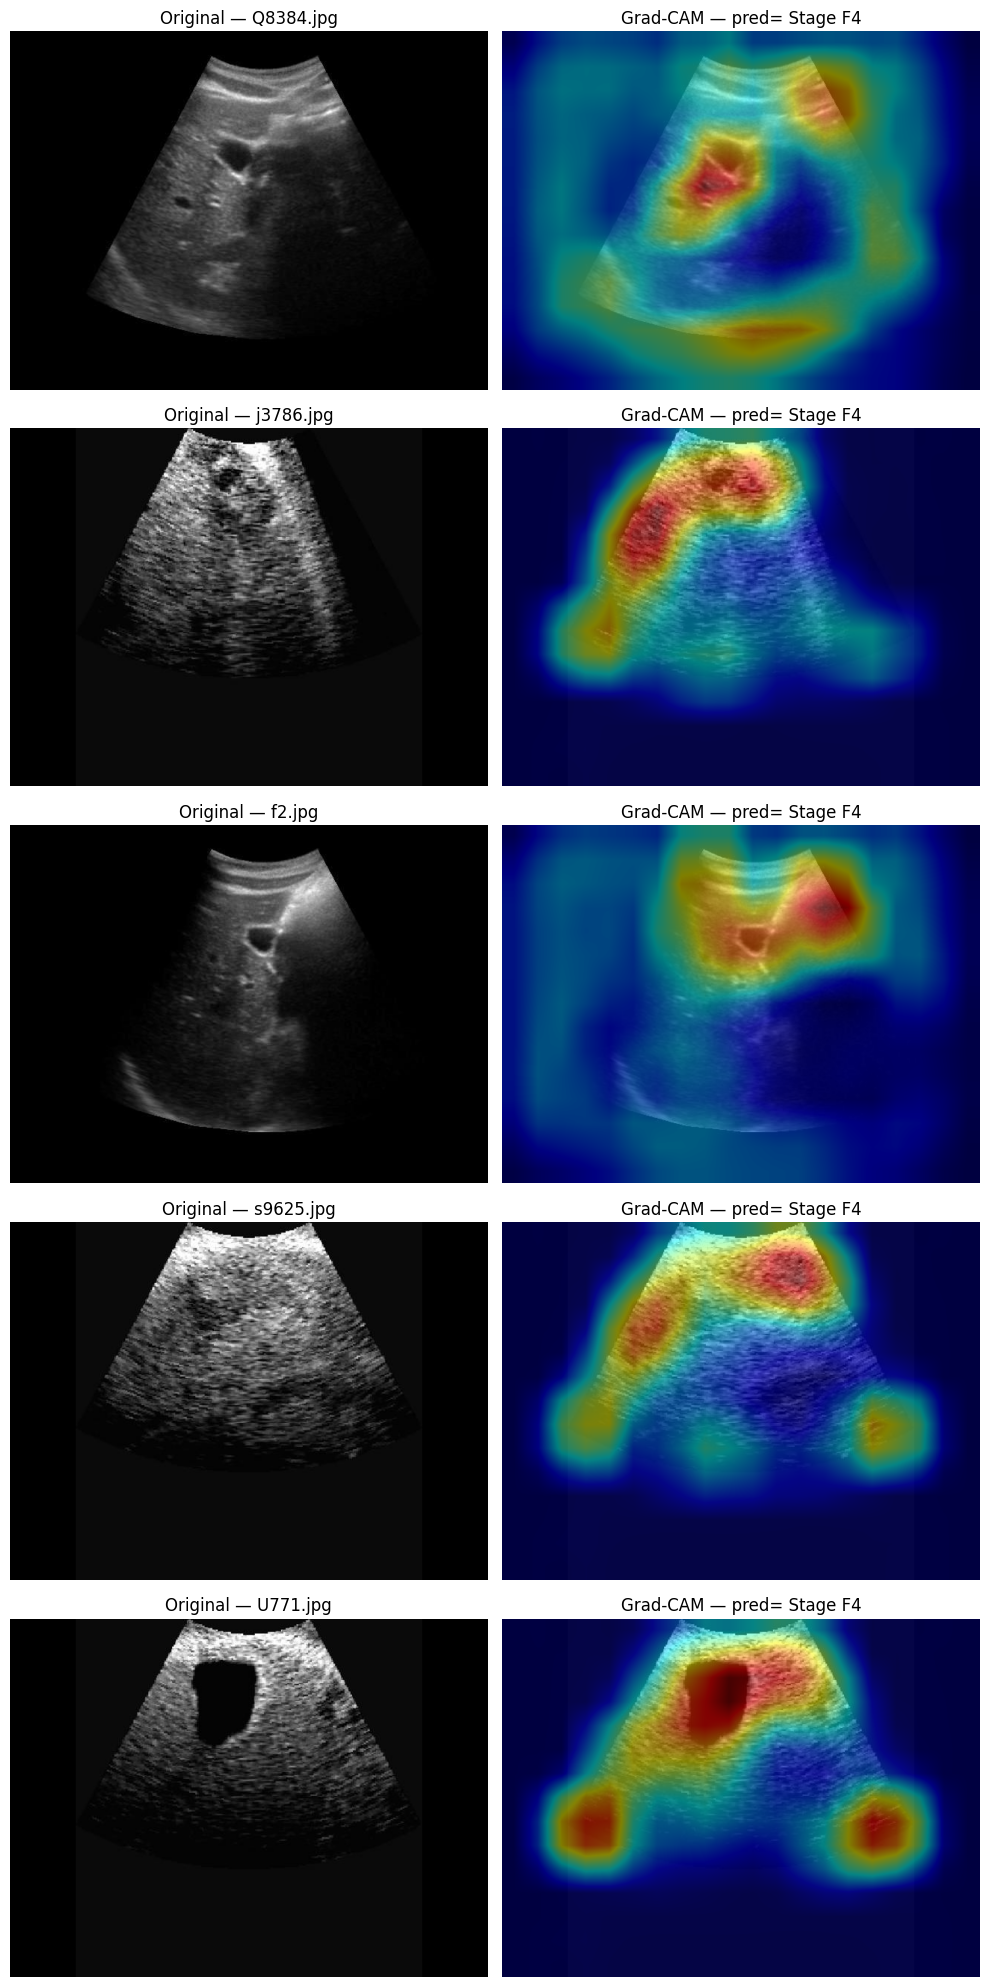

In [96]:
cam = GradCAM(model=densenet_model, target_layers=layers)

plt.figure(figsize=(10, 4 * n_to_show))
for i, img_path in enumerate(selected):
    # load and prepare image (HxWx3 float32 in [0,1])
    img = mpimg.imread(img_path)
    arr = np.array(img)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.shape[2] == 4:
        arr = arr[:, :, :3]
    arr = arr.astype(np.float32)
    if arr.max() > 1.0:
        arr /= 255.0

    # convert to tensor and move to device
    input_tensor = torch.from_numpy(arr).permute(2, 0, 1).unsqueeze(0).to(device)

    # get prediction to target that class
    with torch.no_grad():
        out = densenet_model(input_tensor)
        pred = int(out.argmax(dim=1).item())

    targets = [ClassifierOutputTarget(pred)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

    # overlay and plot
    vis = show_cam_on_image(arr, grayscale_cam, use_rgb=True)

    plt.subplot(n_to_show, 2, 2 * i + 1)
    plt.imshow(arr)
    plt.title(f'Original — {os.path.basename(img_path)}')
    plt.axis('off')

    plt.subplot(n_to_show, 2, 2 * i + 2)
    plt.imshow(vis)
    plt.title(f'Grad-CAM — pred= Stage F{pred + 1}')
    plt.axis('off')

plt.tight_layout()
plt.show()